# River structure and monthly DOC–flow memory

Executed research companion, 2026-10-09. Source-role observations only. The main population has 206 stations, 49 HUC4 regions and 13,846 monthly pairs. Earlier-to-later prediction is possible at 72 stations. In the recent-period sensitivity, previous flow reduces log1p MAE by 9.80% relative to current flow, but the full-period improvement is not established. Structural blocks do not reliably predict the hydrologic-response differences across regions.

## Context and methods

This follow-up adds preceding-calendar-month flow to the previously measured contemporary response. DOC is read only from the frozen source-training union 142/143/144. River units, rather than months, govern inference. Temporal models fit season, trend and flow using earlier observations only. Geographic response models use five whole-HUC4 folds and Ridge alpha=10. Interval estimates preserve whole HUC4 groups and are conditional on saved predictions. All comparisons and sensitivities are retained; intervals are pointwise.

### Key assumptions

Flow is the monthly mean of NWIS daily flow, not instantaneous flow at DOC sampling. Previous-month association is hydrologic memory; it does not measure one-month transport. Seasonal/trend adjustment does not identify causal effects. Original NEON discharge cannot be acquired through the official endpoint without user-authorized authentication; the independent-flow replication is pending.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
study = repo/'experiments/phase4_transfer/doc_river_flow_memory_v1'
counts = pd.read_csv(study/'analysis/population_counts.csv')
display(counts)

,population,n_response_stations,n_response_months,n_response_huc4,n_chronological_stations,n_unique_query_months
0,all_source_months,206,13846,49,72,4722
1,observed_temperature,205,13565,49,69,4566
2,source_months_since_2009,50,5079,23,37,2290


## Paired later-period prediction

Every arm predicts identical later station-months. The following arithmetic recomputes all 18 point estimates directly from saved predictions.

,population,space,gain_pct,ci_low_pct,ci_high_pct,positive_stations,n_stations
1,all_source_months,native,-2.535,-7.817,2.558,44,72
4,all_source_months,log1p,-1.338,-7.944,2.772,45,72
7,observed_temperature,native,-1.513,-3.810,2.778,43,69
10,observed_temperature,log1p,0.810,-1.760,3.386,43,69
13,source_months_since_2009,native,3.011,-3.335,11.300,26,37
16,source_months_since_2009,log1p,9.801,2.006,18.896,26,37


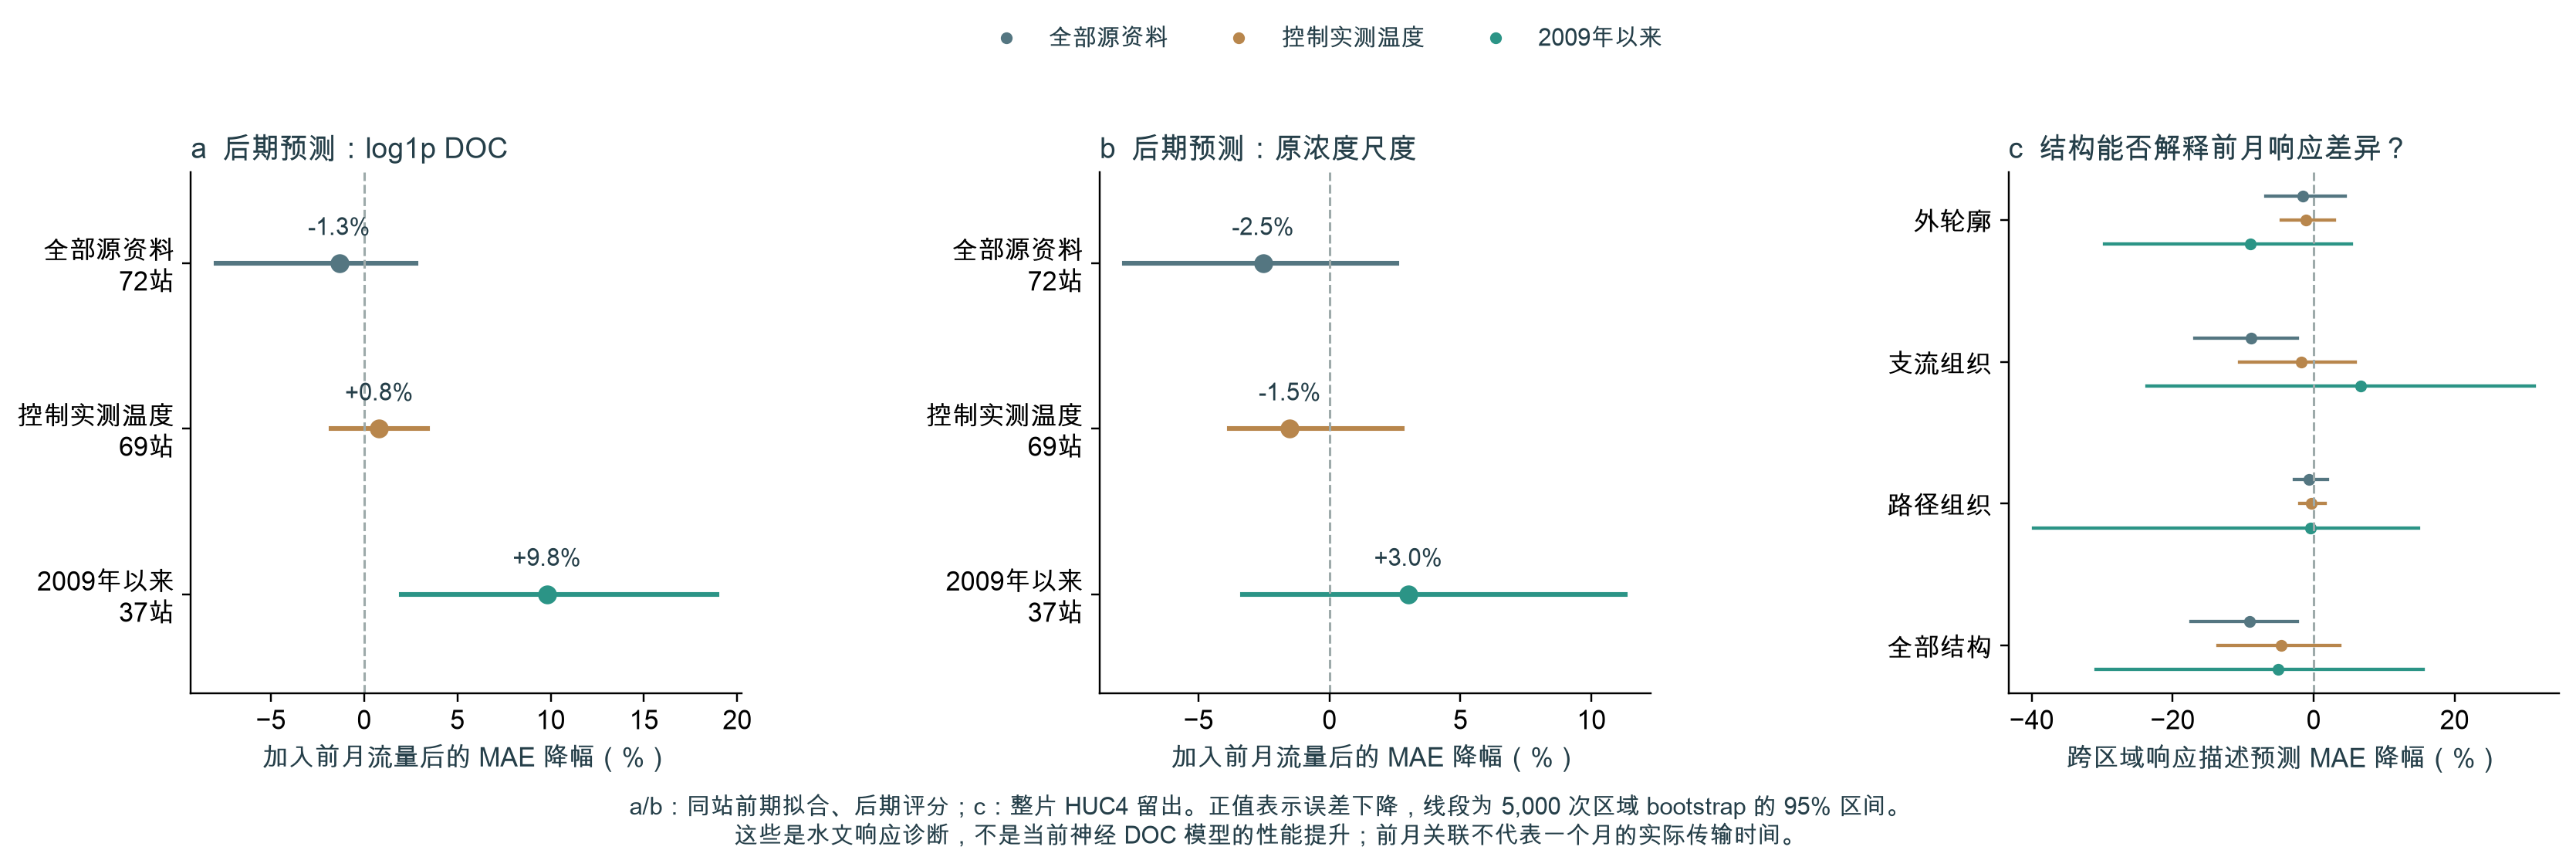

In [2]:
predictions = pd.read_parquet(study/'analysis/chronological_predictions.parquet')
gains = pd.read_csv(study/'analysis/chronological_gains.csv')
for r in gains.itertuples():
    s = predictions[predictions.population.eq(r.population)].copy()
    s['error'] = abs(s.doc-s.prediction) if r.space=='native' else abs(np.log1p(s.doc)-s.log_pred)
    station_errors = s.groupby(['station','arm']).error.mean().unstack()
    base, candidate = station_errors[r.reference].mean(), station_errors[r.candidate].mean()
    np.testing.assert_allclose(100*(base-candidate)/base, r.gain_pct, atol=1e-10)
display(gains[gains.candidate.eq('flow_memory') & gains.reference.eq('current_flow')][['population','space','gain_pct','ci_low_pct','ci_high_pct','positive_stations','n_stations']].round(3))
display(Image(filename=str(study/'figures/river_flow_memory_evidence_cn.png')))

## Geographic structural information

The response being predicted is measured log1p DOC sensitivity to current or previous log flow, rather than production-model DOC. Static shape classes are not reselected using outcomes.

,population,gain_pct,ci_low_pct,ci_high_pct,n_stations,n_huc4
9,all_source_months,-8.928,-16.822,-2.349,206,49
21,observed_temperature,-1.777,-10.537,5.904,205,49
33,source_months_since_2009,6.721,-23.677,31.300,50,23


,response,stations,same_sign_fraction
0,current,72,0.791667
1,previous,72,0.638889


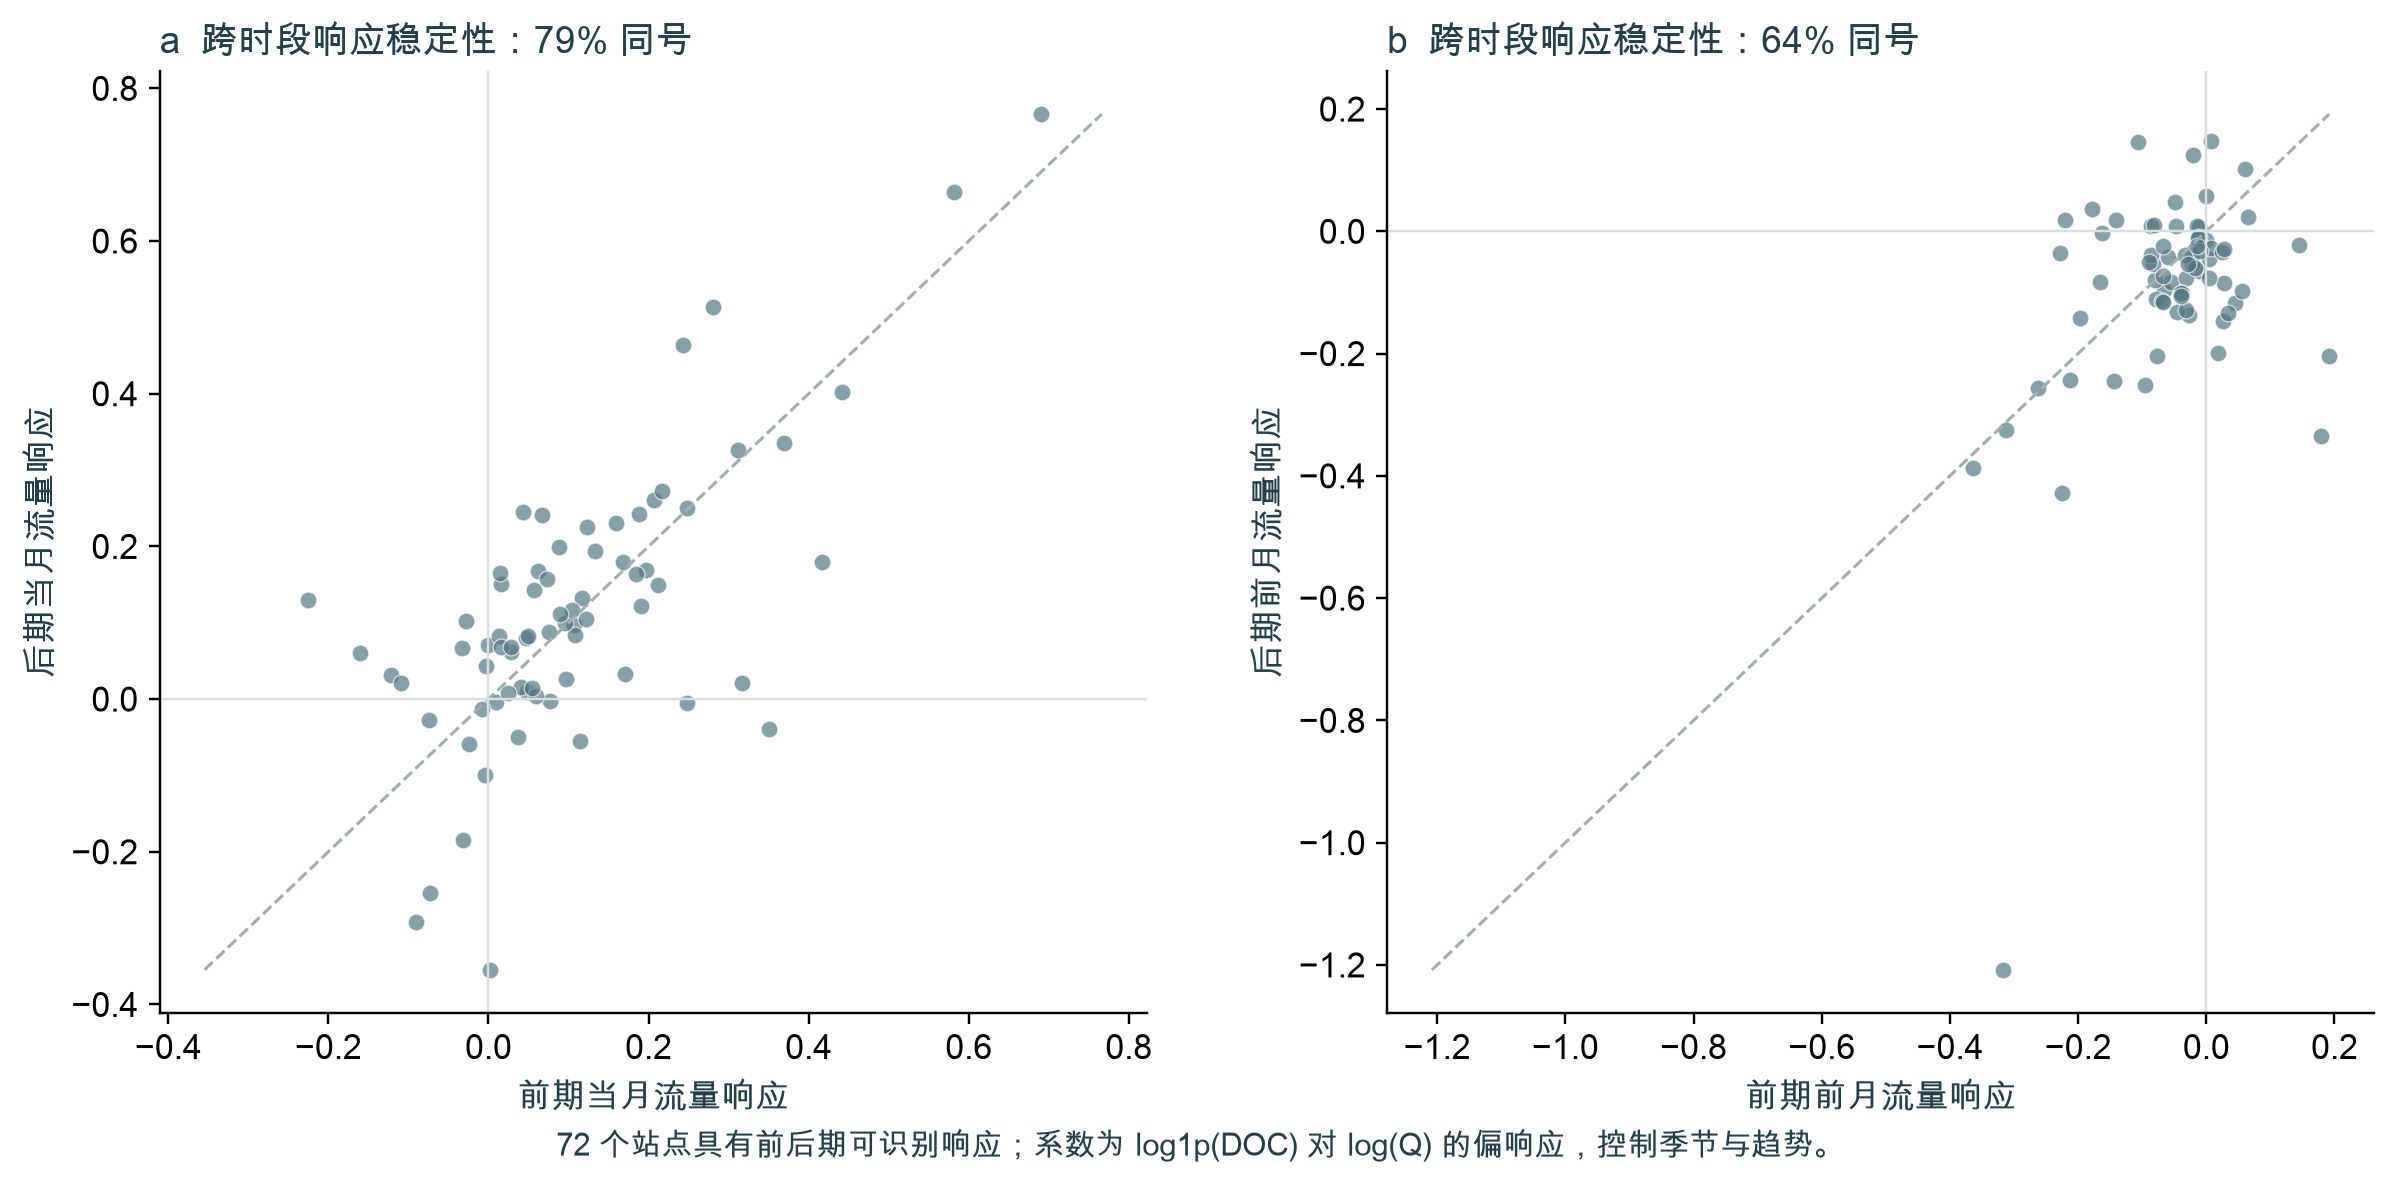

In [3]:
structure = pd.read_csv(study/'analysis/descriptor_gains.csv')
display(structure[structure.candidate.eq('branching') & structure.response.eq('previous_response')][['population','gain_pct','ci_low_pct','ci_high_pct','n_stations','n_huc4']].round(3))
ledger = pd.read_csv(study/'analysis/chronological_eligibility.csv')
s = ledger[ledger.population.eq('all_source_months') & ledger.status.eq('included') & ledger.late_status.eq('included')]
display(pd.DataFrame([{'response':r,'stations':len(s),'same_sign_fraction':np.mean((s[f'train_{r}_response']>0)==(s[f'late_{r}_response']>0))} for r in ['current','previous']]))
display(Image(filename=str(study/'figures/river_flow_response_stability_cn.png')))

## Model destination

The evidence supports checking conditional use of hydrologic history. It does not provide validated shape-specific lag weights or physical concentration constraints. The next model comparison should keep the current complete DOC predictor as the base, control identical static structure inputs, and contrast true upstream state histories against same-input no-message and source-matched non-upstream controls. Previous graph readout experiments already found no increment to the full model; a new test must change the dynamic operator, not relabel the old readout or claim this diagnostic's 9.8% as a GNN gain.

Inputs and calculations are specified in study_plan.md, analysis_sources.json, verification.json and scripts/analyze_doc_river_flow_memory_v1.py.